In [107]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg
import math
import re
import yaml

In [108]:
# Determine the absolute path to the src directory (one level up from notebooks)
module_path = os.path.abspath(os.path.join("..", "src"))
if module_path not in sys.path:
    sys.path.append(module_path)
import plotting
import utils

In [109]:
ROOT_FOLDER = os.path.dirname(os.getcwd())
RUNS_FOLDER = os.path.join(ROOT_FOLDER, "runs")
SINGLE_RUNS_FOLDER = os.path.join(RUNS_FOLDER, "single_runs")
BATCH_RUNS_FOLDER = os.path.join(RUNS_FOLDER, "batch_runs")
DATA_FOLDER = os.path.join(ROOT_FOLDER, "data")
PROCESSED_DATA_FOLDER = os.path.join(DATA_FOLDER, "processed")
CONFIGS_FOLDER = os.path.join(ROOT_FOLDER, "configs")
MODEL_CONFIGS_FOLDER = os.path.join(CONFIGS_FOLDER, "models")

In [110]:
# Load data used for modeling and the results of the model
data_folder_name = "elec_s_37_ES_PT_no_bat_limit"
run_results_folder_name = "May07_Wed_h20-GTSEP_stochastic_v1-37_ES_PT"

In [111]:
# Paths
run_results_folder = os.path.join(SINGLE_RUNS_FOLDER, run_results_folder_name)
model_info_path = os.path.join(run_results_folder, "model_info")
decision_variables_path = os.path.join(run_results_folder, "decision_variables")
dual_variables_path = os.path.join(run_results_folder, "dual_variables")
model_config_path = os.path.join(model_info_path, "config.yaml")

## Read input data

In [112]:
with open(model_config_path, "r") as file:
    model_config = yaml.safe_load(file)
data_folder_name = model_config["data_folder_name"]
VOLL = model_config["VOLL"]
CC = model_config["CC"]
CO2_price = model_config["CO2_price"]
E_limit = model_config["E_limit"]
expansion_factor = model_config["expansion_factor"]
MS = model_config["MS"]
years = model_config["years"]
years = model_config["years"]
representative_period_unit = model_config["representative_period_unit"]
representative_periods = model_config["representative_periods"]
p_max_new_branch = model_config["p_max_new_branch"]
week_weights = model_config["week_weights"]
data_folder = os.path.join(PROCESSED_DATA_FOLDER, data_folder_name)
if representative_period_unit == "week":
    weeks = representative_periods
else:
    print("Error: representative_period_units must be 'week'")

In [113]:
model_config

{'CC': 100,
 'CO2_price': 85,
 'E_limit': inf,
 'MIPGap': 0.01,
 'MS': 0.1,
 'VOLL': 6350,
 'carriers': ['CCGT', 'solar', 'onwind'],
 'clustering_periods': None,
 'clustering_unit': None,
 'data_folder_name': 'elec_s_37_ES_PT_no_bat',
 'discount_rate': 0.07,
 'expansion_factor': 2.0,
 'model_id': '37_ES_PT',
 'model_name': 'GTSEP_stochastic_v1',
 'p_max_new_branch': 5000,
 'p_min_new_branch': 100,
 'query': 'not (x > 2 and y < 40)',
 'representative_period_unit': 'week',
 'representative_periods': [21, 42],
 'run_id': 'May07_Wed_h20-GTSEP_stochastic_v1-37_ES_PT',
 'save_folder': 'C:\\Users\\tinus\\OneDrive\\Dokumenter\\0 Master\\code\\master_project\\runs\\single_runs\\May07_Wed_h20-GTSEP_stochastic_v1-37_ES_PT',
 'scenario_file': None,
 'week_weights': {21: 26.071428571428573, 42: 26.071428571428573},
 'years': [2025, 2030, 2040, 2050]}

In [114]:
input_data = utils.load_multi_year_csv_files_with_week_from_folder(years, data_folder)
input_data.keys()

dict_keys(['batteries', 'branches', 'capacity_factors', 'generators', 'generator_costs', 'hourly_demand', 'nodes'])

In [115]:
batteries = input_data["batteries"]
branches = input_data["branches"]
capacity_factors = input_data["capacity_factors"]
generators = input_data["generators"]
generator_costs = input_data["generator_costs"]
hourly_demand = input_data["hourly_demand"]
nodes = input_data["nodes"]

In [116]:
branches.index.rename({"line": "branch"}, inplace=True)

In [117]:
decision_variables = utils.load_csv_files_from_folder_with_scenarios(
    decision_variables_path
)
battery_capacity = decision_variables["battery_capacity"]
battery_charging = decision_variables["battery_charging"]
battery_discharging = decision_variables["battery_discharging"]
battery_soc = decision_variables["battery_soc"]
branch_capacity = decision_variables["branch_capacity"]
curtailment = decision_variables["curtailment"]
generation = decision_variables["generation"]
generator_capacity = decision_variables["generator_capacity"]
load_shedding = decision_variables["load_shedding"]
power_flow = decision_variables["power_flow"]

In [118]:
# Update generators with new capacity values with investments
gen_ext = generator_capacity.copy()
gen_ext = gen_ext.reindex(generators.index, fill_value=0)

# Step 2: Add 'extended_by' column
generators["extended_by"] = gen_ext["value"]

# Step 3: Calculate cumulative extension for each generator across years
generators = generators.sort_index()  # sort by year and generator
generators["extended_by_cum"] = generators.groupby("generator")["extended_by"].cumsum()

# Step 4: Add total capacity = p_nom + extended_by_cum
generators["total_capacity"] = generators["p_nom"] + generators["extended_by_cum"]

In [119]:
# Set extenstion potential for branches and generators
branches["extension_potential"] = p_max_new_branch * branches["extendable"]
generators["extension_potential"] = (
    generators["p_nom"] * generators["extendable"] * expansion_factor
)

In [120]:
# # Step 1: Copy and align battery_capacity with batteries index
# battery_ext = battery_capacity.copy()
# battery_ext = battery_ext.reindex(batteries.index, fill_value=0)

# # Step 2: Add extension for energy capacity (MWh)
# batteries["extended_by_soc"] = battery_ext["value"]  # MWh

# # Step 3: Add extension for power capacity (MW)
# batteries["extended_by_p"] = (
#     batteries["extended_by_soc"] / batteries["hour_capacity"]
# )  # MW

# # Step 4: Cumulative sums over years (grouped by battery ID)
# batteries = batteries.sort_index()
# batteries["extended_by_soc_cum"] = batteries.groupby("battery")[
#     "extended_by_soc"
# ].cumsum()
# batteries["extended_by_p_cum"] = batteries.groupby("battery")["extended_by_p"].cumsum()

# # Step 5: Set total capacity fields
# batteries["total_energy_capacity"] = batteries["extended_by_soc_cum"]  # MWh
# batteries["total_power_capacity"] = batteries["extended_by_p_cum"]  # MW

In [121]:
# # Update branches with new capacity values with investments


# # Step 1: Ensure 'branches' and 'branch_capacity' are aligned on MultiIndex ["year", "branch"]
# branch_ext = branch_capacity.copy()
# branch_ext = branch_ext.reindex(branches.index, fill_value=0)

# # Step 2: Add 'extended_by' from the decision variable
# branches["extended_by"] = branch_ext["value"]

# # Step 3: Calculate cumulative extension by branch
# branches = branches.sort_index()
# branches["extended_by_cum"] = branches.groupby("branch")["extended_by"].cumsum()

# # Step 4: Add total capacity = p_max + cumulative additions
# branches["total_capacity"] = branches["p_max"] + branches["extended_by_cum"]

In [122]:
# def inspect_dataframes_structure(data: dict[str, pd.DataFrame], n: int = 3) -> None:
#     """
#     Print a structural summary of each dataframe in a dictionary:
#     - Name
#     - Index names
#     - Column names
#     - First n rows
#     """
#     for name, df in data.items():
#         print(f"\n📄 DataFrame: {name}")
#         print(f"Index names: {df.index.names}")
#         print(f"Column names: {list(df.columns)}")
#         print("First few rows:")
#         print(df.head(n))

In [123]:
# inspect_dataframes_structure(input_data)

In [124]:
dual_variables = utils.load_csv_files_from_folder_with_scenarios(dual_variables_path)

In [125]:
dual_variables.keys()

dict_keys(['battery_charge_new_max_duals', 'battery_charge_old_duals', 'battery_discharge_new_max_duals', 'battery_discharge_old_duals', 'branch_extension_duals', 'branch_flow_new_duals', 'branch_flow_old_duals', 'emissions_duals', 'gen_extension_duals', 'gen_output_new_duals', 'gen_output_old_duals', 'load_shedding_duals', 'power_balance_duals'])

In [126]:
emissions_dual = dual_variables["emissions_duals"]
gen_output_new_duals = dual_variables["gen_output_new_duals"]
gen_output_old_duals = dual_variables["gen_output_old_duals"]
branch_flow_new_duals = dual_variables["branch_flow_new_duals"]
branch_flow_old_duals = dual_variables["branch_flow_old_duals"]
load_shedding_duals = dual_variables["load_shedding_duals"]
power_balance_duals = dual_variables["power_balance_duals"]
branch_extension_duals = dual_variables["branch_extension_duals"]
gen_extension_duals = dual_variables["gen_extension_duals"]

In [127]:
if gen_output_new_duals.equals(gen_output_old_duals):
    print("✅ gen_output_new_duals is equal to the old duals")
else:
    print("❌ gen_output_new_duals is not equal to the old duals")

if branch_flow_new_duals.equals(branch_flow_old_duals):
    print("✅ branch_flow_new_duals is equal to the old duals")
else:
    print("❌ branch_flow_new_duals is not equal to the old duals")

❌ gen_output_new_duals is not equal to the old duals
❌ branch_flow_new_duals is not equal to the old duals


In [128]:
# inspect_dataframes_structure(dual_variables)

In [129]:
# Flip sign to get shadow prices (economic value of more generation)
gen_output_new_duals["shadow_price"] = -gen_output_new_duals["dual_value"]

# Filter for binding constraints (positive shadow price)
binding_duals = gen_output_new_duals[gen_output_new_duals["shadow_price"] > 1e-5]

# Group by generator: compute mean, max, and count of binding hours
constrained_stats = (
    binding_duals.groupby("generator")["shadow_price"]
    .agg(["mean", "max", "count"])
    .rename(columns={"count": "binding_hours"})
)

# Add total hours per generator from the full dataset
total_hours = gen_output_new_duals.index.get_level_values("generator").value_counts()
constrained_stats["total_hours"] = constrained_stats.index.map(total_hours)

# Calculate how often each generator is constrained
constrained_stats["binding_ratio"] = (
    constrained_stats["binding_hours"] / constrained_stats["total_hours"]
)

# Sort by mean shadow price (most valuable constraints)
constrained_stats = constrained_stats.sort_values(by="mean", ascending=False)

In [130]:
constrained_stats

,mean,max,binding_hours,total_hours,binding_ratio
generator,,,,,
ES1 0 CCGT,1591.899305,3146.113810,2,2352,0.000850
ES1 0 offwind-ac,33.776462,3174.992500,1434,2352,0.609694
ES1 0 onwind,33.776462,3174.992500,1434,2352,0.609694
PT1 0 offwind-ac,24.239595,3239.788418,2031,2352,0.863520
PT1 0 onwind,24.239595,3239.788418,2031,2352,0.863520
ES1 0 solar,22.785330,3174.995000,2126,2352,0.903912
PT1 0 ror,20.939736,3239.795918,2352,2352,1.000000
PT1 0 solar,20.934022,3239.790918,2352,2352,1.000000
ES1 0 ror,20.601637,3175.000000,2352,2352,1.000000


In [131]:
threshold = 1000
high_duals = gen_output_new_duals[
    gen_output_new_duals["shadow_price"] > threshold
].copy()


high_duals = high_duals.reset_index().sort_values(by="shadow_price", ascending=False)


print(f"High dual entries (shadow_price > {threshold}):")
high_duals

High dual entries (shadow_price > 1000):


,generator,scenario,year,week,hour,dual_value,shadow_price
9,PT1 0 ror,DE,2050,42,90,-3239.795918,3239.795918
10,PT1 0 solar,DE,2050,42,90,-3239.790918,3239.790918
7,PT1 0 offwind-ac,DE,2050,42,90,-3239.788418,3239.788418
8,PT1 0 onwind,DE,2050,42,90,-3239.788418,3239.788418
6,PT1 0 CCGT,DE,2050,42,90,-3211.857570,3211.857570
4,ES1 0 ror,DE,2050,42,90,-3175.000000,3175.000000
5,ES1 0 solar,DE,2050,42,90,-3174.995000,3174.995000
2,ES1 0 offwind-ac,DE,2050,42,90,-3174.992500,3174.992500
3,ES1 0 onwind,DE,2050,42,90,-3174.992500,3174.992500
1,ES1 0 coal,DE,2050,42,90,-3146.451515,3146.451515


In [132]:
load_shedding

value
node  scenario year week hour       
ES1 0 NT       2025 21   0       0.0
                         1       0.0
                         2       0.0
                         3       0.0
                         4       0.0
...                              ...
PT1 0 DE       2050 42   163     0.0
                         164     0.0
                         165     0.0
                         166     0.0
                         167     0.0

[4704 rows x 1 columns]

In [133]:
merged = high_duals.merge(
    load_shedding.reset_index(),
    on=["year", "week", "hour"],
    how="left",
    suffixes=("", "_load_shed"),
)

# See if any load was shed at these high-dual hours
print("\nLoad shedding in high-dual hours:")
print(merged[merged["value"] > 1e-3].sort_values("shadow_price", ascending=False))


Load shedding in high-dual hours:
           generator scenario  year  week  hour   dual_value  shadow_price  \
1          PT1 0 ror       DE  2050    42    90 -3239.795918   3239.795918   
3          PT1 0 ror       DE  2050    42    90 -3239.795918   3239.795918   
5        PT1 0 solar       DE  2050    42    90 -3239.790918   3239.790918   
7        PT1 0 solar       DE  2050    42    90 -3239.790918   3239.790918   
9   PT1 0 offwind-ac       DE  2050    42    90 -3239.788418   3239.788418   
11  PT1 0 offwind-ac       DE  2050    42    90 -3239.788418   3239.788418   
13      PT1 0 onwind       DE  2050    42    90 -3239.788418   3239.788418   
15      PT1 0 onwind       DE  2050    42    90 -3239.788418   3239.788418   
17        PT1 0 CCGT       DE  2050    42    90 -3211.857570   3211.857570   
19        PT1 0 CCGT       DE  2050    42    90 -3211.857570   3211.857570   
23         ES1 0 ror       DE  2050    42    90 -3175.000000   3175.000000   
21         ES1 0 ror       DE

In [134]:
# Merge generation with capacity factors
dispatch = generation.reset_index()
cf = capacity_factors.reset_index()
dispatch = dispatch.merge(cf, on=["year", "week", "hour"])

# Get the installed capacity (p_nom) from the generators dataframe
dispatch["total_capacity"] = dispatch.apply(
    lambda row: (
        generators.loc[(row["year"], row["generator"]), "total_capacity"]
        if (row["year"], row["generator"]) in generators.index
        else None
    ),
    axis=1,
)

# Get the correct column name from capacity_factors: it's dynamic, e.g. "PT1 0 solar"
# Use the row's generator as a column name to extract the capacity factor
dispatch["cf"] = dispatch.apply(lambda row: row.get(row["generator"], None), axis=1)

# Calculate the theoretical output cap
dispatch["dispatch_limit"] = dispatch["total_capacity"] * dispatch["cf"]

# Calculate utilization ratio
dispatch["utilization"] = dispatch["value"] / dispatch["dispatch_limit"]

In [135]:
# Get just year, week, hour combinations of interest
high_hours = high_duals[["year", "week", "hour"]].drop_duplicates()

# Merge to get dispatch in those hours only
dispatch_high = dispatch.merge(high_hours, on=["year", "week", "hour"])

# Look at generators near or at their cap
near_limit = dispatch_high[dispatch_high["utilization"] >= 0.95]

# View summary
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    print("\nGenerators near their limit during high-dual hours:")
    print(
        near_limit[
            [
                "year",
                "week",
                "hour",
                "generator",
                "value",
                "dispatch_limit",
                "utilization",
            ]
        ]
    )


Generators near their limit during high-dual hours:
    year  week  hour         generator         value  dispatch_limit  \
1   2050    42    90        ES1 0 CCGT  26305.332000    26305.332000   
2   2050    42    90        ES1 0 coal   4739.393483     4739.393483   
3   2050    42    90        ES1 0 coal   4739.393483     4739.393483   
4   2050    42    90  ES1 0 offwind-ac   2599.743938      866.581313   
5   2050    42    90  ES1 0 offwind-ac   2599.743938      866.581313   
6   2050    42    90      ES1 0 onwind   4315.363268     1206.788176   
7   2050    42    90      ES1 0 onwind   4315.363268     1206.788176   
8   2050    42    90         ES1 0 ror      7.200443        7.200443   
9   2050    42    90         ES1 0 ror      7.200443        7.200443   
12  2050    42    90        PT1 0 CCGT  15146.633580     4145.000000   
13  2050    42    90        PT1 0 CCGT  15146.633580     4145.000000   
14  2050    42    90  PT1 0 offwind-ac    133.384053       44.461351   
15  2050   

In [136]:
# Extract and drop duplicates
near_limit_timesteps = near_limit[["year", "week", "hour"]].drop_duplicates()

# Reset index for convenience
near_limit_timesteps = near_limit_timesteps.reset_index(drop=True)

# Display result
print("Timesteps when at least one generator was near its limit:")
print(near_limit_timesteps)

Timesteps when at least one generator was near its limit:
   year  week  hour
0  2050    42    90


In [137]:
key_times = set(
    [tuple(x) for x in near_limit_timesteps[["year", "week", "hour"]].values]
)
key_times

{(2050, 42, 90)}

In [138]:
# Filter generation
gen_filtered = generation.reset_index()
gen_filtered = gen_filtered[
    gen_filtered[["year", "week", "hour"]].apply(tuple, axis=1).isin(key_times)
]

# Filter capacity factors
cf_filtered = capacity_factors.reset_index()
cf_filtered = cf_filtered[
    cf_filtered[["year", "week", "hour"]].apply(tuple, axis=1).isin(key_times)
]

# Step 2: Merge generation with capacity factors
gen_cf = gen_filtered.merge(cf_filtered, on=["year", "week", "hour"])

# Step 3: Add total_capacity from generators
gen_cf["total_capacity"] = gen_cf.apply(
    lambda row: (
        generators.loc[(row["year"], row["generator"]), "total_capacity"]
        if (row["year"], row["generator"]) in generators.index
        else None
    ),
    axis=1,
)

# Step 4: Add capacity factor (the column name is the generator name)
gen_cf["cf"] = gen_cf.apply(lambda row: row.get(row["generator"], None), axis=1)

# Step 5: Compute dispatch limit
gen_cf["dispatch_limit"] = gen_cf["total_capacity"] * gen_cf["cf"]

# Step 6: Output generation vs dispatch limit
gen_cf["utilization_ratio"] = gen_cf["value"] / gen_cf["dispatch_limit"]

# Optional: clean up and sort
result = gen_cf[
    [
        "year",
        "week",
        "hour",
        "generator",
        "value",
        "dispatch_limit",
        "utilization_ratio",
    ]
]
result = result.sort_values(by=["year", "week", "hour", "generator"]).reset_index(
    drop=True
)

# Display the final result
print("Generation vs theoretical maximum at near-limit timesteps:")
print(result)

Generation vs theoretical maximum at near-limit timesteps:
    year  week  hour         generator         value  dispatch_limit  \
0   2050    42    90        ES1 0 CCGT  22612.637190    26305.332000   
1   2050    42    90        ES1 0 CCGT  26305.332000    26305.332000   
2   2050    42    90        ES1 0 coal   4739.393483     4739.393483   
3   2050    42    90        ES1 0 coal   4739.393483     4739.393483   
4   2050    42    90  ES1 0 offwind-ac   2599.743938      866.581313   
5   2050    42    90  ES1 0 offwind-ac   2599.743938      866.581313   
6   2050    42    90      ES1 0 onwind   4315.363268     1206.788176   
7   2050    42    90      ES1 0 onwind   4315.363268     1206.788176   
8   2050    42    90         ES1 0 ror      7.200443        7.200443   
9   2050    42    90         ES1 0 ror      7.200443        7.200443   
10  2050    42    90       ES1 0 solar      0.000000        0.000000   
11  2050    42    90       ES1 0 solar      0.000000        0.000000   
12  2

In [139]:
# Merge generation duals with load shedding to compare
gen_duals = gen_output_new_duals["dual_value"].reset_index()
gen_duals["shadow_price"] = -gen_duals["dual_value"]

load_shed = load_shedding["value"].reset_index()
merged = pd.merge(gen_duals, load_shed, on=["year", "week", "hour"], how="left")

# Only keep rows where shadow price is near VOLL
threshold = 0.95 * VOLL
high_dual_hours = merged[merged["shadow_price"] >= threshold]

# Display some high-dual entries with load shedding info
print("\nHigh-dual hours and associated load shedding:")
with pd.option_context("display.max_rows", None):
    print(high_dual_hours.sort_values(by="shadow_price", ascending=False))


High-dual hours and associated load shedding:
Empty DataFrame
Columns: [generator, scenario_x, year, week, hour, dual_value, shadow_price, node, scenario_y, value]
Index: []


In [140]:
prev_key_times = set(
    (year, week, hour - 1)
    for year, week, hour in near_limit_timesteps[["year", "week", "hour"]].values
)


print(prev_key_times)

{(2050, 42, 89)}


In [141]:
# Step 1: Prepare key times from near_limit_timesteps
key_times = set(tuple(x) for x in near_limit_timesteps[["year", "week", "hour"]].values)

# Step 2: Filter battery SOC and discharge for relevant timesteps
discharge_filtered = battery_discharging.reset_index()
soc_filtered = battery_soc.reset_index()

# Filter for target hours
discharge_filtered = discharge_filtered[
    discharge_filtered[["year", "week", "hour"]].apply(tuple, axis=1).isin(key_times)
]
soc_current = soc_filtered[
    soc_filtered[["year", "week", "hour"]].apply(tuple, axis=1).isin(key_times)
]
prev_key_times = {(year, week, hour - 1) for year, week, hour in key_times}
# Step 3: Compute previous time steps
soc_prev = soc_filtered[
    soc_filtered[["year", "week", "hour"]].apply(tuple, axis=1).isin(prev_key_times)
]


# Rename column for clarity
soc_prev = soc_prev.rename(columns={"value": "value_soc_prev"})
soc_prev["hour"] = soc_prev["hour"] + 1

# Step 4: Merge current SOC with previous SOC
soc_merged = soc_current.merge(
    soc_prev[["year", "week", "hour", "battery", "value_soc_prev"]],
    on=["year", "week", "hour", "battery"],
    how="left",
)

# Step 5: Merge with discharge
battery_status = discharge_filtered.merge(
    soc_merged,
    on=["year", "week", "hour", "battery"],
    how="inner",
    suffixes=("_discharge", "_soc"),
)

# Step 6: Add cumulative capacity info from batteries
battery_status["SOC_max_frac"] = battery_status.apply(
    lambda row: (
        batteries.loc[(row["year"], row["battery"]), "SOC_max"]
        if (row["year"], row["battery"]) in batteries.index
        else None
    ),
    axis=1,
)
battery_status["total_energy_capacity"] = battery_status.apply(
    lambda row: (
        batteries.loc[(row["year"], row["battery"]), "total_energy_capacity"]
        if (row["year"], row["battery"]) in batteries.index
        else None
    ),
    axis=1,
)
battery_status["total_power_capacity"] = battery_status.apply(
    lambda row: (
        batteries.loc[(row["year"], row["battery"]), "total_power_capacity"]
        if (row["year"], row["battery"]) in batteries.index
        else None
    ),
    axis=1,
)

# Step 7: Compute max SOC and ratios
battery_status["SOC_max"] = (
    battery_status["SOC_max_frac"] * battery_status["total_energy_capacity"]
)
battery_status["soc_ratio"] = battery_status["value_soc"] / battery_status["SOC_max"]
battery_status["discharge_ratio"] = (
    battery_status["value_discharge"] / battery_status["total_power_capacity"]
)
battery_status["soc_ratio_prev"] = (
    battery_status["value_soc_prev"] / battery_status["SOC_max"]
)

# Step 8: Final cleaned-up output
battery_usage_summary = (
    battery_status[
        [
            "year",
            "week",
            "hour",
            "battery",
            "value_discharge",
            "total_power_capacity",
            "discharge_ratio",
            "value_soc_prev",
            "value_soc",
            "SOC_max",
            "soc_ratio_prev",
            "soc_ratio",
        ]
    ]
    .sort_values(by=["year", "week", "hour", "battery"])
    .reset_index(drop=True)
)

with pd.option_context("display.max_rows", None, "display.max_columns", None):
    print("Battery usage summary:")
    print(battery_usage_summary)

Battery usage summary:
Empty DataFrame
Columns: [year, week, hour, battery, value_discharge, total_power_capacity, discharge_ratio, value_soc_prev, value_soc, SOC_max, soc_ratio_prev, soc_ratio]
Index: []


## What can be said about the duals for the power generation?

3a\. **Generator output limits (existing generators)**

$$
P_{i}^{\min} \leq g_{i,y,w,t} \leq P_{i}^{\max} cf_{i,y,w,t}, \quad \forall i \in G^{old},y,w,t
$$

3b\. **Generator output limits (new generators)**

$$
0 \leq g_{i,y,w,t} \leq cf_{i,y,w,t}\sum_{y'\in Y_y}p_{i,y'}^{max}, \quad \forall i \in G^{new},y,w,t
$$

Observations:
- The duals are >9000 at some time steps in year 2045. At those times (3 consecutive time steps), there is full utilization of ALL generators capacity, the branches are flowing at max capacity and both batteries are full at the beginning and then is depleted almost fully by the end.
- There is no load shedding at those time steps.

What is causing the price of approximately 9000-10000?  

In [142]:
generator_capacity

value
generator        year              
ES1 0 CCGT       2025      0.000000
                 2030      0.000000
                 2040      0.000000
                 2050      0.000000
ES1 0 coal       2025      0.000000
                 2030      0.000000
                 2040      0.000000
                 2050      0.000000
ES1 0 offwind-ac 2025  18548.926971
                 2030      0.000000
                 2040      0.000000
                 2050      0.000000
ES1 0 onwind     2025  53651.725339
                 2030  15449.223940
                 2040      0.000000
                 2050      0.000000
ES1 0 ror        2025      0.000000
                 2030      0.000000
                 2040      0.000000
                 2050      0.000000
ES1 0 solar      2025  23363.158546
                 2030  23363.158546
                 2040  17441.108900
                 2050      0.000000
PT1 0 CCGT       2025   8290.000000
                 2030   2711.633580
                 2040      0.000000
                 2050      0.000000
PT1 0 offwind-ac 2025   8920.377472
                 2030      0.000000
                 2040      0.000000
                 2050      0.000000
PT1 0 onwind     2025  10427.281351
                 2030      0.000000
                 2040      0.000000
                 2050      0.000000
PT1 0 ror        2025      0.000000
                 2030      0.000000
                 2040      0.000000
                 2050      0.000000
PT1 0 solar      2025   2050.880000
                 2030   2050.880000
                 2040      0.000000
                 2050      0.000000

This shows that CCGT is the next generator to be bought in 2045 since it is the only invested in generator that is not fully utilized. However, the price of investing in another unit of CCGT is over 99000, so it doesn't quite make sense why the price of the dual is around 9000.

## MAYDAY MAYDAY
I figured out what is causing the wierd values. The duals measures the change in objective value. The objective value consists of operational costs which are multiplied by a weighing factor. Therefore, to get the actual price of the dual, I need to divide by the weighing factor. Furthermore, the objective value is divided by the number of years. Therefore, I need to multiply by the number of year to get the actual price. Alternatively, I should just remove the divide by the number of years in the objective function, so I maintain actual values and instead can do the calculation to yearly values in the post-optimization analyzes.

### Frequency diagram of the duals

In [143]:
generators["production_cost"] = (
    generators["marginal_cost"] + generators["co2_emissions"] * CO2_price
)
generators["production_cost"].loc[2025]

generator
ES1 0 CCGT          57.772380
ES1 0 coal          57.096970
ES1 0 offwind-ac     0.015000
ES1 0 onwind         0.015000
ES1 0 ror            0.000000
ES1 0 solar          0.010000
PT1 0 CCGT          55.876697
PT1 0 offwind-ac     0.015000
PT1 0 onwind         0.015000
PT1 0 ror            0.000000
PT1 0 solar          0.010000
Name: production_cost, dtype: float64

In [144]:
import pandas as pd
import numpy as np

# Step 1: Count dual value frequencies
dual_value_counts = (
    gen_output_old_duals["dual_value"]
    .value_counts()
    .rename_axis("dual_value")
    .reset_index(name="frequency")
    .sort_values("dual_value")
)

# Step 2: Round duals for display only (keep original for matching)
dual_value_counts["dual_value_display"] = dual_value_counts["dual_value"].round(3)

# Step 3: Get production costs and corresponding target duals
production_costs = generators["production_cost"].loc[2025].round(5).reset_index()
production_costs.columns = ["generator", "production_cost"]
production_costs["dual_target"] = -production_costs[
    "production_cost"
]  # duals are negative

# Group by unique dual_target
cost_to_generators = (
    production_costs.groupby("dual_target")["generator"].apply(list).reset_index()
)

# Step 4: Fuzzy match function with ±0.01 tolerance
tolerance = 0.05


def match_dual_to_generators(dual_val):
    matches = cost_to_generators[
        np.abs(cost_to_generators["dual_target"] - dual_val) <= tolerance
    ]
    if matches.empty:
        return pd.Series([np.nan, np.nan])
    # If multiple match, combine all
    gens = sum(matches["generator"].tolist(), [])
    if len(gens) > 1:
        gens = ["renewable"]
    return pd.Series([matches["dual_target"].values[0], gens])


# Apply fuzzy matching
dual_value_counts[["matched_production_cost", "matched_generators"]] = (
    dual_value_counts["dual_value"].apply(match_dual_to_generators)
)

# Step 5: Filter only frequencies > 10
filtered_dual_value_counts = dual_value_counts[dual_value_counts["frequency"] > 10]

# Step 6: Final cleaned dataframe
dual_cost_table = filtered_dual_value_counts[
    ["dual_value_display", "frequency", "matched_production_cost", "matched_generators"]
].rename(
    columns={
        "dual_value_display": "dual_value",
        "matched_production_cost": "prod_cost",
        "matched_generators": "generators",
        "frequency": "f",
    }
)

# Display full output
with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "expand_frame_repr", False
):
    print("Dual values with fuzzy-matched generators (±0.01), frequency > 10:")
    print(dual_cost_table)

Dual values with fuzzy-matched generators (±0.01), frequency > 10:
     dual_value     f  prod_cost    generators
69      -58.951    79        NaN           NaN
71      -58.941    79        NaN           NaN
39      -58.936   158        NaN           NaN
94      -58.262    36        NaN           NaN
95      -58.252    36        NaN           NaN
74      -58.247    72        NaN           NaN
66      -57.772    90  -57.77238  [ES1 0 CCGT]
64      -57.762    90  -57.77238  [ES1 0 CCGT]
32      -57.757   180  -57.77238  [ES1 0 CCGT]
87      -57.097    45  -57.09697  [ES1 0 coal]
86      -57.087    45  -57.09697  [ES1 0 coal]
63      -57.082    90  -57.09697  [ES1 0 coal]
20      -55.877   275  -55.87670  [PT1 0 CCGT]
21      -55.867   275  -55.87670  [PT1 0 CCGT]
4       -55.862   550  -55.87670  [PT1 0 CCGT]
24      -54.759   255        NaN           NaN
23      -54.749   255        NaN           NaN
5       -54.744   510        NaN           NaN
60      -29.476   116        NaN        

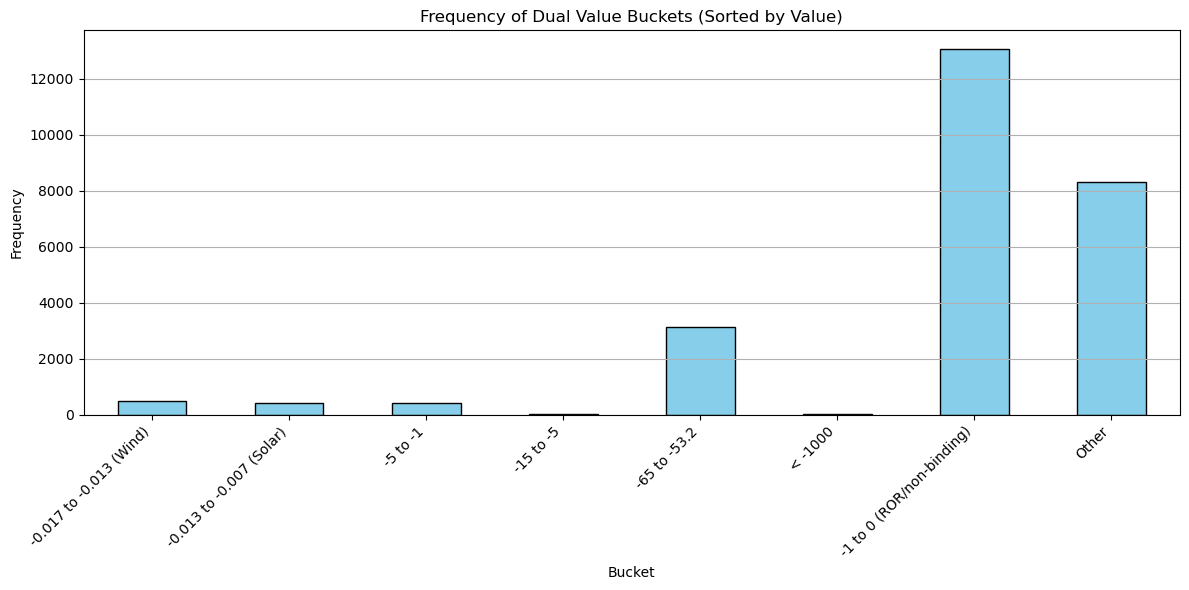

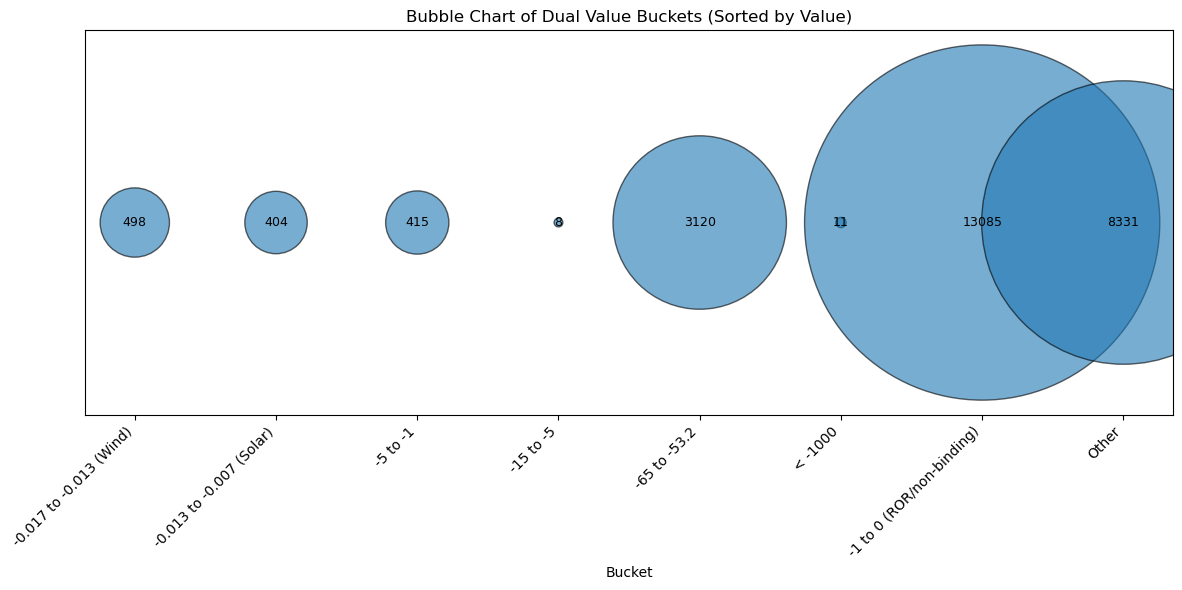

In [145]:
# Re-run necessary imports and data setup after code execution environment reset

import matplotlib.pyplot as plt
import pandas as pd


# Bucket labeling function
def label_dual_bucket(val):
    if val < -1000:
        return "< -1000"
    elif -700 <= val < -600:
        return "-700 to -600"
    elif -65 <= val <= -53.2:
        return "-65 to -53.2"
    elif -60.5 < val <= -57.5:
        return "-60.5 to -57.5 (ES CCGT)"
    elif -57.5 < val <= -56.5:
        return "-57.5 to -56.5 (ES coal)"
    elif -56.5 < val <= -54.5:
        return "-56.5 to -54.5 (PT CCGT)"
    elif -15 <= val < -5:
        return "-15 to -5"
    elif -5 <= val < -1:
        return "-5 to -1"
    elif -0.017 < val <= -0.013:
        return "-0.017 to -0.013 (Wind)"
    elif -0.013 <= val <= -0.007:
        return "-0.013 to -0.007 (Solar)"
    elif -1 <= val <= 0.001:
        return "-1 to 0 (ROR/non-binding)"
    else:
        return "Other"


# Apply buckets
dual_value_counts["bucket"] = dual_value_counts["dual_value"].apply(label_dual_bucket)

# Define numeric order for sorting
bucket_order = [
    "-0.017 to -0.013 (Wind)",
    "-0.013 to -0.007 (Solar)",
    "-5 to -1",
    "-15 to -5",
    "-65 to -53.2",
    "-56.5 to -54.5 (PT CCGT)",
    "-57.5 to -56.5 (ES coal)",
    "-60.5 to -57.5 (ES CCGT)",
    "-700 to -600",
    "< -1000",
    "1 to 5",
    "5 to 15",
    "15 to 53",
    "-1 to 0 (ROR/non-binding)",
    "Other",
]

# Group and sort
bucket_counts = (
    dual_value_counts.groupby("bucket")["frequency"]
    .sum()
    .reindex(bucket_order)
    .dropna()
)

# --- Bar Chart ---
plt.figure(figsize=(12, 6))
bucket_counts.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Frequency of Dual Value Buckets (Sorted by Value)")
plt.ylabel("Frequency")
plt.xlabel("Bucket")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

# --- Bubble Chart ---
plt.figure(figsize=(12, 6))
plt.scatter(
    x=bucket_counts.index,
    y=[1] * len(bucket_counts),
    s=bucket_counts.values * 5,
    alpha=0.6,
    edgecolors="black",
)

# Annotate bubbles
for i, (label, freq) in enumerate(bucket_counts.items()):
    plt.text(label, 1, str(int(freq)), ha="center", va="center", fontsize=9)

plt.title("Bubble Chart of Dual Value Buckets (Sorted by Value)")
plt.xlabel("Bucket")
plt.yticks([])
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.grid(axis="y")
plt.show()

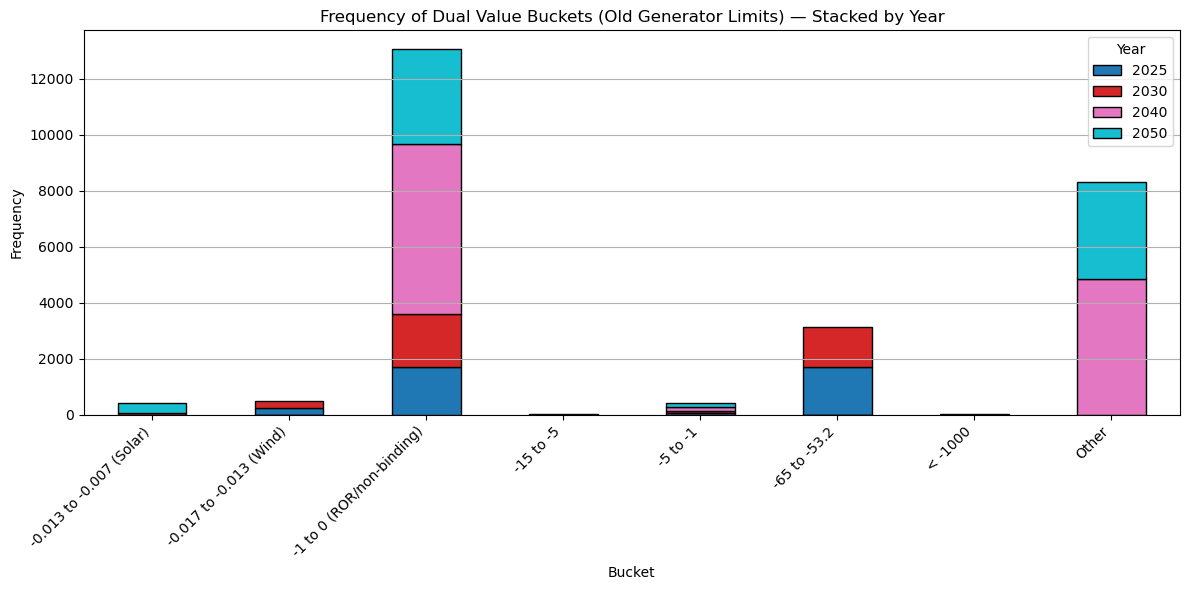

In [146]:
# Step 1: Rebuild dual_value_counts with year info
dual_value_counts_by_year = (
    gen_output_old_duals.reset_index()
    .groupby(["year", "dual_value"])
    .size()
    .reset_index(name="frequency")
)
dual_value_counts_by_year["bucket"] = dual_value_counts_by_year["dual_value"].apply(
    label_dual_bucket
)

# Step 3: Aggregate frequencies per bucket and year
bucket_counts_by_year = (
    dual_value_counts_by_year.groupby(["bucket", "year"])["frequency"]
    .sum()
    .unstack(fill_value=0)
)

# Step 5: Plot
bucket_counts_by_year.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    edgecolor="black",
    colormap="tab10",
)

plt.title("Frequency of Dual Value Buckets (Old Generator Limits) — Stacked by Year")
plt.xlabel("Bucket")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.legend(title="Year")
plt.show()

## Demand duals


In [147]:
# Prepare data
pb_duals = power_balance_duals.reset_index()
pb_duals["shadow_price"] = pb_duals["dual_value"]

# Summary stats: mean, max, and count per node
node_stats = (
    pb_duals.groupby("node")["shadow_price"]
    .agg(["mean", "max", "count"])
    .rename(columns={"count": "total_hours"})
    .sort_values("mean", ascending=False)
)

with pd.option_context("display.max_rows", None):
    print("Power balance dual stats by node:")
    print(node_stats)

Power balance dual stats by node:
            mean          max  total_hours
node                                      
PT1 0  20.939736  3239.795918         2352
ES1 0  20.601637  3175.000000         2352


In [148]:
# Filter where shadow price is above 95% of VOLL
high_pb_duals = pb_duals[
    pb_duals["shadow_price"] >= 0.3 * pb_duals["shadow_price"].max()
].copy()
high_pb_duals = high_pb_duals.sort_values(by="shadow_price", ascending=False)

print("High power balance duals (≥ 30% max dual):")
print(high_pb_duals)

High power balance duals (≥ 30% max dual):
       node scenario  year  week  hour   dual_value  shadow_price
4626  PT1 0       DE  2050    42    90  3239.795918   3239.795918
2274  ES1 0       DE  2050    42    90  3175.000000   3175.000000


In [149]:
# Frequency of dual values (rounded for clarity)
pb_duals["dual_value_rounded"] = pb_duals["shadow_price"].round(3)

dual_counts = (
    pb_duals["dual_value_rounded"]
    .value_counts()
    .rename_axis("dual_value")
    .reset_index(name="frequency")
    .sort_values("dual_value")
)

print("Dual value frequencies:")
print(dual_counts)

Dual value frequencies:
    dual_value  frequency
8        0.003        252
0        0.005        682
17       0.007         75
6        0.008        265
19       0.010         64
1        0.015        498
29       0.543          1
24       0.554          1
28       8.517          1
27       8.691          1
3       18.253        346
2       18.626        413
15      19.032         84
10      19.257        178
20      19.421         48
11      19.650        147
9       27.380        222
4       27.938        279
18      28.548         65
12      28.886        145
22      29.131         37
13      29.476        116
7       54.759        255
5       55.877        275
21      57.097         45
14      57.772         90
23      58.262         36
16      58.951         79
25      66.571          1
31      67.930          1
26    3175.000          1
30    3239.796          1


<Figure size 1400x600 with 0 Axes>

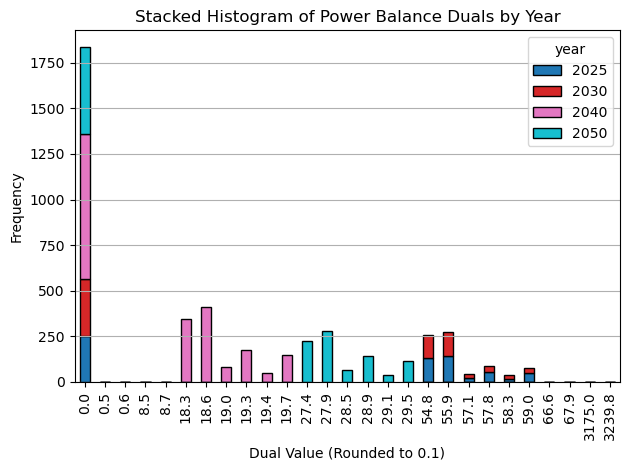

In [150]:
# Add rounded value for histogram binning
pb_duals["dual_value_bin"] = pb_duals["shadow_price"].round(1)

# Create histogram grouped by year
hist_by_year = pb_duals.groupby(["dual_value_bin", "year"]).size().unstack(fill_value=0)

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
hist_by_year.plot(kind="bar", stacked=True, colormap="tab10", edgecolor="black")
plt.title("Stacked Histogram of Power Balance Duals by Year")
plt.xlabel("Dual Value (Rounded to 0.1)")
plt.ylabel("Frequency")
plt.xticks(rotation=90)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [151]:
generators["production_cost"].loc[2025]

generator
ES1 0 CCGT          57.772380
ES1 0 coal          57.096970
ES1 0 offwind-ac     0.015000
ES1 0 onwind         0.015000
ES1 0 ror            0.000000
ES1 0 solar          0.010000
PT1 0 CCGT          55.876697
PT1 0 offwind-ac     0.015000
PT1 0 onwind         0.015000
PT1 0 ror            0.000000
PT1 0 solar          0.010000
Name: production_cost, dtype: float64

In [152]:
load_shedding.sum()

value    2552.896926
dtype: float64

## Calculate co2 emissions

In [153]:
len(generation)

25872

In [154]:
# Calculate co2 emissions
generation_copy = generation.copy()
generation_copy.reset_index(inplace=True)
generators_copy = generators.copy()
generators_copy.reset_index(inplace=True)
merged = generation_copy.merge(
    generators_copy[["year", "generator", "co2_emissions"]],
    on=["year", "generator"],
    how="left",
)
print(len(merged))
merged["co2_production"] = merged["value"] * merged["co2_emissions"]

merged["week_weight"] = merged["week"].map(week_weights)
# print(merged)
merged["weighted_co2"] = merged["co2_production"] * merged["week_weight"]

print(f"CO2 emitted: {merged['weighted_co2'].sum() / 1e6:.2f} Million tons")
print(f"Total CO2 cost: {merged['weighted_co2'].sum() * CO2_price / 1e6:.2f} Million €")

25872
CO2 emitted: 111.96 Million tons
Total CO2 cost: 9516.99 Million €


In [155]:
generation

value
generator   scenario year week hour             
ES1 0 CCGT  NT       2025 21   0        0.000000
                               1        0.000000
                               2      331.376520
                               3     1230.225647
                               4     3463.006762
...                                          ...
PT1 0 solar DE       2050 42   163      0.000000
                               164      0.000000
                               165      0.000000
                               166      0.000000
                               167      0.000000

[25872 rows x 1 columns]

## Power flow duals

In [156]:
dual_variables.keys()

dict_keys(['battery_charge_new_max_duals', 'battery_charge_old_duals', 'battery_discharge_new_max_duals', 'battery_discharge_old_duals', 'branch_extension_duals', 'branch_flow_new_duals', 'branch_flow_old_duals', 'emissions_duals', 'gen_extension_duals', 'gen_output_new_duals', 'gen_output_old_duals', 'load_shedding_duals', 'power_balance_duals'])

## Load shedding duals

In [157]:
# Prep: convert to shadow price (economic value of reduced shedding)
ls_duals = load_shedding_duals.reset_index()
ls_duals["shadow_price"] = ls_duals["dual_value"]

# Summary stats per node
ls_stats = (
    ls_duals.groupby("node")["shadow_price"]
    .agg(["mean", "max", "count"])
    .rename(columns={"count": "total_hours"})
    .sort_values("mean", ascending=False)
)

print("Load shedding dual stats by node:")
print(ls_stats)

Load shedding dual stats by node:
           mean  max  total_hours
node                             
ES1 0  0.000000  0.0         2352
PT1 0 -0.027549  0.0         2352


In [158]:
# Duals near VOLL indicate load shedding is valuable to avoid
binding_ls = ls_duals[ls_duals["shadow_price"] >= 0.3 * ls_duals["shadow_price"].max()]

print("Binding load shedding duals (≥ 95% of VOLL):")
print(binding_ls.sort_values(by="shadow_price", ascending=False))

Binding load shedding duals (≥ 95% of VOLL):
       node scenario  year  week  hour  dual_value  shadow_price
0     ES1 0       NT  2025    21     0         0.0           0.0
3124  PT1 0       NT  2040    21   100         0.0           0.0
3140  PT1 0       NT  2040    21   116         0.0           0.0
3139  PT1 0       NT  2040    21   115         0.0           0.0
3138  PT1 0       NT  2040    21   114         0.0           0.0
...     ...      ...   ...   ...   ...         ...           ...
1567  ES1 0       DE  2040    42    55         0.0           0.0
1566  ES1 0       DE  2040    42    54         0.0           0.0
1565  ES1 0       DE  2040    42    53         0.0           0.0
1564  ES1 0       DE  2040    42    52         0.0           0.0
4703  PT1 0       DE  2050    42   167         0.0           0.0

[4703 rows x 7 columns]


In [159]:
# Round for better binning
ls_duals["dual_value_rounded"] = ls_duals["shadow_price"].round(3)

# Frequency table
dual_freq = (
    ls_duals["dual_value_rounded"]
    .value_counts()
    .rename_axis("dual_value")
    .reset_index(name="frequency")
    .sort_values("dual_value")
)

print("Frequency of load shedding dual values:")
print(dual_freq)

Frequency of load shedding dual values:
   dual_value  frequency
1     -64.796          1
0       0.000       4703


<Figure size 1400x600 with 0 Axes>

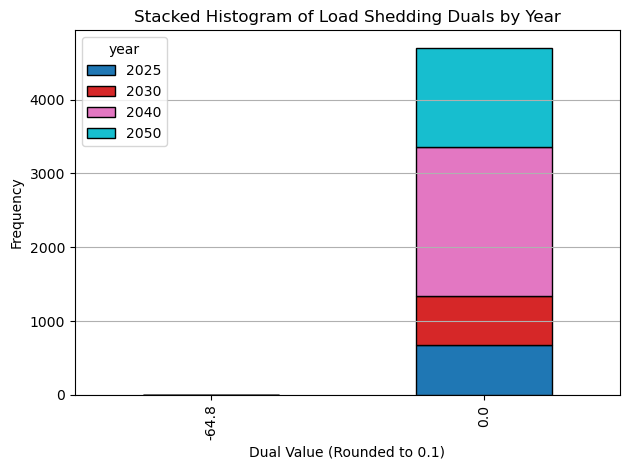

In [160]:
import matplotlib.pyplot as plt

# Bin rounded to 1 decimal
ls_duals["dual_bin"] = ls_duals["shadow_price"].round(1)

# Group for histogram
hist = ls_duals.groupby(["dual_bin", "year"]).size().unstack(fill_value=0)

# Plot
plt.figure(figsize=(14, 6))
hist.plot(kind="bar", stacked=True, edgecolor="black", colormap="tab10")
plt.title("Stacked Histogram of Load Shedding Duals by Year")
plt.xlabel("Dual Value (Rounded to 0.1)")
plt.ylabel("Frequency")
plt.xticks(rotation=90)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [161]:
dual_variables.keys()

dict_keys(['battery_charge_new_max_duals', 'battery_charge_old_duals', 'battery_discharge_new_max_duals', 'battery_discharge_old_duals', 'branch_extension_duals', 'branch_flow_new_duals', 'branch_flow_old_duals', 'emissions_duals', 'gen_extension_duals', 'gen_output_new_duals', 'gen_output_old_duals', 'load_shedding_duals', 'power_balance_duals'])

## Branch flow duals

In [162]:
# Step 1: Combine old + new duals and reset index
branch_flow_old_duals_labeled = branch_flow_old_duals.copy().reset_index()
branch_flow_old_duals_labeled["asset_type"] = "old"

branch_flow_new_duals_labeled = branch_flow_new_duals.copy().reset_index()
branch_flow_new_duals_labeled["asset_type"] = "new"

branch_flow_duals = pd.concat(
    [branch_flow_old_duals_labeled, branch_flow_new_duals_labeled], ignore_index=True
)

# Step 2: Add shadow price and filter binding ones
branch_flow_duals["shadow_price"] = -branch_flow_duals["dual_value"]
binding_duals = branch_flow_duals[branch_flow_duals["shadow_price"] > 1e-5]

# Step 3: Compute stats grouped by branch/bound/asset_type
constrained_stats = (
    binding_duals.groupby(["branch", "bound", "asset_type"])["shadow_price"]
    .agg(["mean", "max", "count"])
    .rename(columns={"count": "binding_hours"})
)

# Step 4: Total hours the constraint was evaluated
total_hours = (
    branch_flow_duals.groupby(["branch", "bound", "asset_type"])
    .size()
    .rename("total_hours")
)

# Step 5: Merge and calculate binding ratio
constrained_stats = constrained_stats.join(total_hours)
constrained_stats["binding_ratio"] = (
    constrained_stats["binding_hours"] / constrained_stats["total_hours"]
)

# Step 6: Sort and display
constrained_stats = constrained_stats.sort_values(by="mean", ascending=False)

# Show the result
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    print("Branch flow constraint dual stats (old + new):")
    print(constrained_stats)

Branch flow constraint dual stats (old + new):
Empty DataFrame
Columns: [mean, max, binding_hours, total_hours, binding_ratio]
Index: []


## Extension (investment) duals

In [163]:
# --- Common processing function ---
def analyze_extension_duals(duals_df, asset_df, asset_col="generator"):
    # Reset index to get 'year' and asset_col as columns
    df = duals_df.reset_index()

    # Add shadow price (positive value of dual)
    df["shadow_price"] = df["dual_value"]  # dual is already positive if binding

    # Filter binding duals
    df = df[df["shadow_price"] < -1e-5]

    # Add extension potential
    df["extension_potential"] = df.apply(
        lambda row: (
            asset_df.loc[(row["year"], row[asset_col]), "extension_potential"]
            if (row["year"], row[asset_col]) in asset_df.index
            else None
        ),
        axis=1,
    )

    # Calculate potential value (shadow_price × extension_potential)
    df["potential_value_of_capacity"] = df["shadow_price"] * df["extension_potential"]

    # Summarize stats
    summary = (
        df.groupby([asset_col])
        .agg(
            mean_shadow_price=("shadow_price", "mean"),
            max_shadow_price=("shadow_price", "max"),
            binding_years=("year", "count"),
            total_potential_value=("potential_value_of_capacity", "sum"),
        )
        .sort_values(by="mean_shadow_price", ascending=False)
    )

    return summary


# --- Apply to generator extensions ---
gen_ext_stats = analyze_extension_duals(
    duals_df=gen_extension_duals,
    asset_df=generators,
    asset_col="generator",
)

# --- Apply to branch extensions ---
branch_ext_stats = analyze_extension_duals(
    duals_df=branch_extension_duals,
    asset_df=branches,
    asset_col="branch",
)

# --- View summaries ---
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    print("🔋 Generator Extension Dual Summary:")
    print(gen_ext_stats)
    print("\n🔌 Branch Extension Dual Summary:")
    print(branch_ext_stats)

🔋 Generator Extension Dual Summary:
                  mean_shadow_price  max_shadow_price  binding_years  \
generator                                                              
PT1 0 CCGT             -5047.432460      -5047.432460              1   
ES1 0 offwind-ac       -6452.566946      -6452.566946              1   
PT1 0 onwind          -15036.850062     -15036.850062              1   
PT1 0 solar           -30148.447545     -15275.162869              2   
ES1 0 onwind          -30518.503162     -30518.503162              1   
ES1 0 solar           -31108.269126     -15313.502586              2   
PT1 0 offwind-ac      -49261.068865     -49261.068865              1   

                  total_potential_value  
generator                                
PT1 0 CCGT                -4.184322e+07  
ES1 0 offwind-ac          -1.196882e+08  
PT1 0 onwind              -1.567935e+08  
PT1 0 solar               -1.236617e+08  
ES1 0 onwind              -1.637370e+09  
ES1 0 solar          

In [164]:
gen_extension_duals.describe()

,dual_value
count,44.000000
mean,-5200.678519
std,12900.212342
min,-49261.068865
25%,0.000000
50%,0.000000
75%,0.000000
max,0.000000


In [165]:
branch_extension_duals.describe()

,dual_value
count,4.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0
